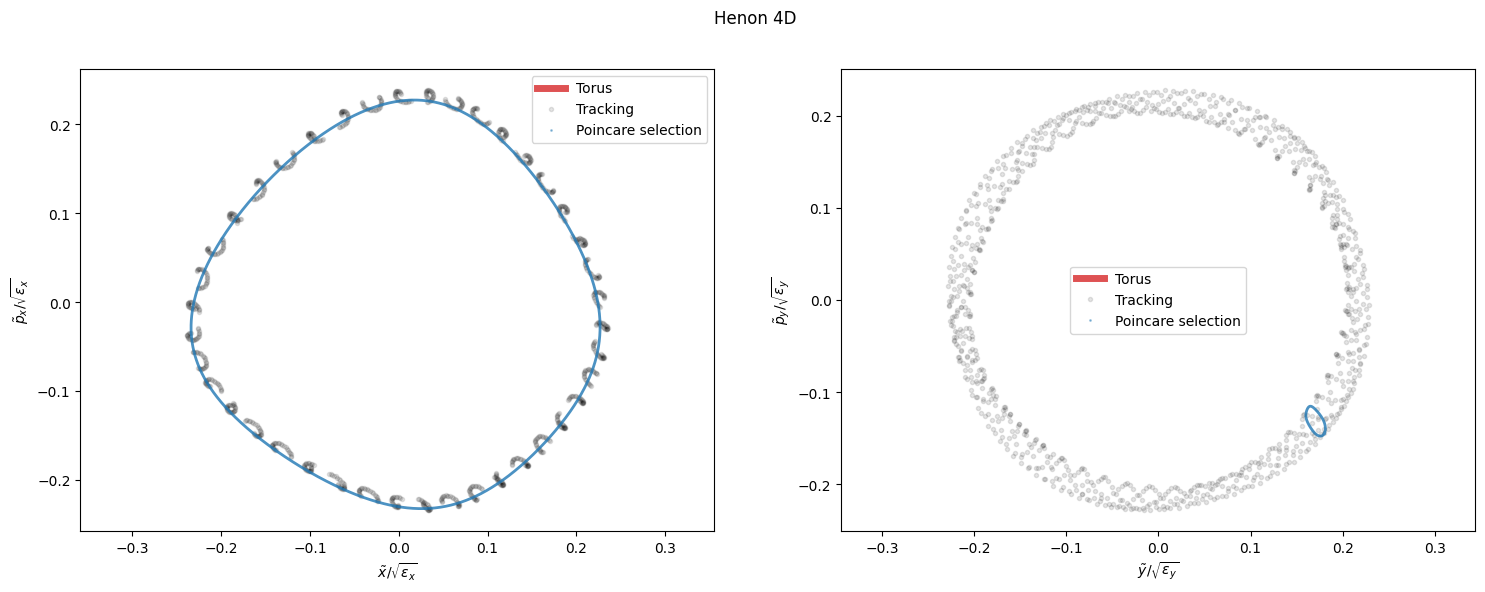

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sciStat
import nafflib

import sys
sys.path.append('/Users/pbelanger/ABPLocal/pytori')
import pytori.torus as pytorus




# Henon parameters:
# ---
nturns = int(1e6)

points = np.array([0.2])

slope  = 0.35

coupling = 0.25
Qx_list = [0.2064898024701758,0.2264898024701758, (3 - np.sqrt(5)) / 2]
Qx = 0.24464898024701758
Qy = np.sqrt(2) - 1
# ------------

particles = []
for point in points:
    
    # Tracking
    x,px,y,py = nafflib.henon_map_4D(point,slope*point,point,slope*point,   Qx = Qx,
                                                                            Qy = Qy,
                                                                            coupling = coupling,
                                                                            num_turns= nturns)
    # Saving
    dct = {'x':x,'px':px,'y':y,'py':py}
    particles.append(dct)


    
n_harm = 200
from fractions import Fraction
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.suptitle('Henon 4D')
for p_idx,part in enumerate(particles):
    
    fundamental_tunes = [nafflib.tune(part[plane][:int(5e4)],part[f'p{plane}'][:int(5e4)],window_order=4) for plane in ['x','y']]

    N_start = 10


    Ax,Qx  = nafflib.harmonics( part['x'][:int(5e4)],part[f'px'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cx,err,_f = nafflib.find_linear_combinations(Qx,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)

    Ay,Qy  = nafflib.harmonics( part['y'][:int(5e4)],part[f'py'][:int(5e4)],num_harmonics = n_harm,window_order=4)
    Cy,err,_f = nafflib.find_linear_combinations(Qy,fundamental_tunes=fundamental_tunes,max_harmonic_order=40)

    mytorus = pytorus.Torus(Ax,Ay,Cx,Cy)
        

    theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,1000)
    theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start
        

    slice_x,slice_y = mytorus.slice('x',theta_vec,theta_slice)
    slice_x,slice_y = slice_x[0],slice_y[0]



    plt.sca(axes[0])
    plane = 'x'
    plt.plot(slice_x[:,0],slice_x[:,1],'-',lw=2,alpha=0.8,zorder=-10)
    plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)


    plt.sca(axes[1])
    plane = 'y'
    plt.plot(slice_y[:,0],slice_y[:,1],'-',lw=2,alpha=0.8,zorder=-10)
    plt.plot(part[plane][:1000],part[f'p{plane}'][:1000],'.',color='k',alpha=0.1,zorder=-20)

# Adding labels
for plane,ax in zip(['x','y','zeta'],axes):
    plt.sca(ax)
    plt.axis('equal')
    if plane == 'zeta':
        plane = '\zeta'
    plt.xlabel(rf'$\tilde {plane}/\sqrt{{\varepsilon_{plane}}}$')
    plt.ylabel(rf'$\tilde p_{plane}/\sqrt{{\varepsilon_{plane}}}$')

    plt.plot(np.nan,np.nan,'-',lw=5,color='C3',alpha=0.8,zorder=-10,label='Torus')
    plt.plot(np.nan,np.nan,'.',color='k',alpha=0.1,label='Tracking')
    plt.plot(np.nan,np.nan,'.',ms=2,color='C0',alpha=0.4,label='Poincare selection')

    plt.legend()

    # plt.xlim(-0.5,0.5)
    # plt.ylim(-0.5,0.5)


plt.sca(axes[0])
# plt.xlim(-0.5,-0.25)
# plt.ylim(0,0.2)



In [70]:
mytorus.Ax

array([ 2.02450146e-01-9.01288977e-02j,  9.80394406e-03+9.47974080e-03j,
        3.34273199e-04+9.41602687e-03j, -8.74761439e-03-1.63064461e-05j,
        3.00682036e-03+7.49549685e-03j, -4.97018838e-03-4.18159292e-03j,
       -1.02460313e-03-1.13787956e-03j, -5.58637724e-04+5.36148824e-04j,
        4.40901858e-04-4.91447690e-04j,  5.98180097e-04-3.17521478e-04j,
       -5.64483357e-04-2.04694919e-04j, -1.97567943e-04+4.87238731e-04j,
       -4.42936975e-04+1.61534921e-04j, -1.73511663e-04-3.53585183e-04j,
        1.73424125e-04-3.55044270e-04j,  8.99827857e-05-2.75138967e-04j,
       -1.89636343e-04-1.34886753e-05j,  6.11677962e-06+5.82469868e-05j,
        1.91837869e-06-5.69714296e-05j, -1.69259272e-05-5.24147615e-05j,
        4.28069022e-05-3.12337425e-06j,  1.34430200e-06-3.42638215e-05j,
       -2.85650636e-05-1.28447132e-05j, -2.70103873e-05-7.72984650e-06j,
       -9.75433399e-06+1.25141724e-05j, -1.14973645e-05-8.38811996e-06j,
        5.71186740e-06+1.18050764e-05j,  1.29186286

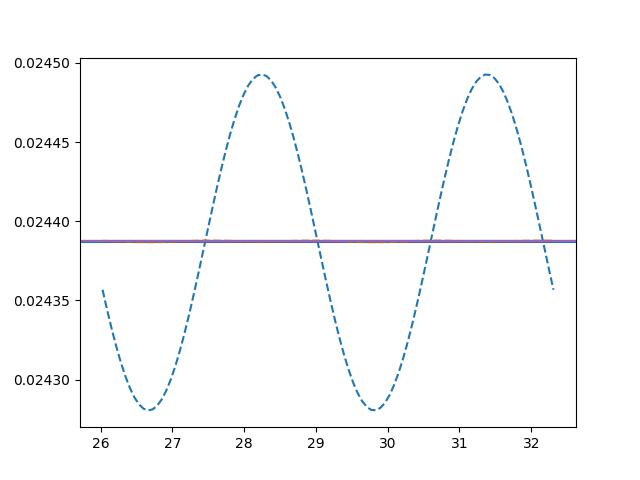

In [5]:

from shapely import Polygon  

theta_vec   = 2 * np.pi*fundamental_tunes[0]* N_start + np.linspace(0,2*np.pi,5000)
theta_slice = 2 * np.pi*fundamental_tunes[1]* N_start + np.linspace(0,2*np.pi,100)

plt.figure()
for stop_at,color in zip([10,20,50,100,200],['C0','C1','C2','C3','C4']):
    mytorus_test = pytorus.Torus(mytorus.Ax[:stop_at],mytorus.Ay[:stop_at],mytorus.nx[:stop_at],mytorus.ny[:stop_at])
    slice_x,slice_y = mytorus_test.slice('x',theta_vec,theta_slice)

    Ixx = []
    Ixy = []
    Ix  = []
    Jx  = []
    for _sx,_sy,id in zip(slice_x,slice_y,np.arange(len(slice_x))):
        
        x_polygon = Polygon([(_x,_px) for _x,_px in zip(_sx[:,0],_sx[:,1])])
        y_polygon = Polygon([(_x,_px) for _x,_px in zip(_sy[:,0],_sy[:,1])])

        
        Ixx.append(x_polygon.area)
        Ixy.append(-y_polygon.area)
        Ix.append(x_polygon.area - y_polygon.area)

        Jx.append(np.mean(_sx[:,0]**2 + _sx[:,1]**2))

    Ixx = np.array(Ixx)/np.pi/2
    Ixy = np.array(Ixy)/np.pi/2
    Ix  = np.array(Ix)/np.pi/2
    Jx  = np.array(Jx)/2


    
    # plt.plot(theta_slice,   Ixx + (Ix[0]-Ixx[0])    ,'-',color='C0' ,lw=4,alpha=0.3,label='Ixx')
    # plt.plot(theta_slice,   Ixy + (Ix[0]-Ixy[0])    ,'-',color='C1' ,lw=4,alpha=0.3,label='Ixy')
    # plt.plot(theta_slice,   Ix                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
    # plt.plot(theta_slice,   Jx                      ,'-',color='k'  ,lw=4,alpha=0.3,label='Jx')

    area_test = np.array([compute_area(mytorus_test,theta) for theta in theta_slice])
    # plt.plot(theta_slice,   area_test[:,0]+ (Ix[0]-area_test[:,0][0])    ,'--' ,label='Ixx_test')
    # plt.plot(theta_slice,   area_test[:,1]+ (Ix[0]-area_test[:,1][0])    ,'--' ,label='Ixy_test')

    # plt.axhline(mytorus.Ix,ls='--',color='C4')

    plt.plot(theta_slice,np.sum(area_test,axis=1),'--',color=color)
    plt.axhline(mytorus_test.Ix,ls='-',color=color)
# plt.legend()
plt.show()


In [2]:
%matplotlib widget

In [89]:
plt.figure()
# plt.plot(theta_slice,   Ixy + Ixx                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice,np.sum(area_test,axis=1),'--',color='C3')
plt.axhline(mytorus.Ix,ls='--',color='C4')


<IPython.core.display.Javascript object>

In [7]:
np.mean(np.sum(area_test,axis=1)) - mytorus.Ix

1.3475331961387838e-14

In [62]:
(np.max(np.sum(area_test,axis=1)) - np.min(np.sum(area_test,axis=1)))/2

2.0284988966334794e-12

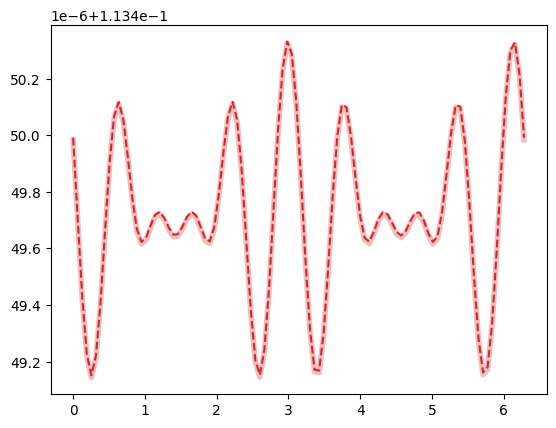

In [38]:
plt.figure()
plt.plot(theta_slice,   Ixy + Ixx                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice,np.sum(area_test,axis=1),'--',color='C3')


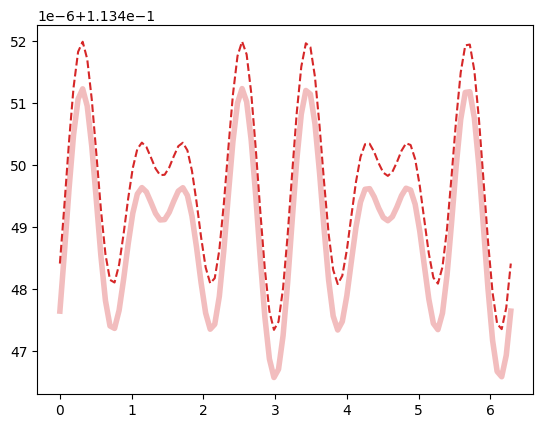

In [30]:
plt.figure()
plt.plot(theta_slice,   Ixy + Ixx                      ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice,np.sum(area_test,axis=1),'--',color='C3')


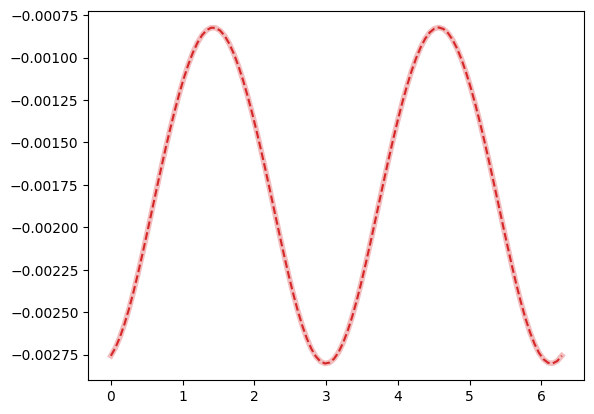

In [29]:
plt.figure()
plt.plot(theta_slice,   Ixy  ,'-',color='C3' ,lw=4,alpha=0.3,label='Ix')
plt.plot(theta_slice, area_test[:,1] ,'--',color='C3')

In [11]:
area_test = np.array([compute_area(mytorus,theta) for theta in theta_slice])

In [4]:
def compute_area(torus,theta):
    phi = [n[1]*theta + np.angle(A) for n,A in zip(torus.nx,torus.Ax)]
    a   = [np.abs(A) for A in torus.Ax]

    Ixx_area = 1/2 * sum(ak*aj*nj[0]*np.cos(phij-phik) for nk,ak,phik in zip(torus.nx,a,phi) for nj,aj,phij in zip(torus.nx,a,phi) if nj[0]==nk[0])


    phi = [n[1]*theta + np.angle(A) for n,A in zip(torus.ny,torus.Ay)]
    a   = [np.abs(A) for A in torus.Ay]

    Iyy_area = 1/2 * sum(ak*aj*nj[0]*np.cos(phij-phik) for nk,ak,phik in zip(torus.ny,a,phi) for nj,aj,phij in zip(torus.ny,a,phi) if nj[0]==nk[0])
    
    return Ixx_area,Iyy_area


